# EGGA-Error-Guided-Generative-AI-and-Optimized-Machine-Learning-based-Intrusion-Detection-System 
This is the code for the paper entitled "[**EGGA-Error-Guided-Generative-AI-and-Optimized-Machine-Learning-based-Intrusion-Detection-System**](https://www.mdpi.com/1999-5903/18/4/202)" published in Future Internet (IF: 3.6).  
Authors: Li Yang (liyanghart@gmail.com) and G. Kirubavathi  

If you find this repository useful in your research, please cite this article as:  
Yang, L.; Kirubavathi, G. EGGA: An Error-Guided Generative Augmentation and Optimized ML-Based IDS for EV Charging Network Security. _Future Internet_ **2026**, 18, 202. https://doi.org/10.3390/fi18040202  

```
@Article{fi18040202,
AUTHOR = {Yang, Li and Kirubavathi, G.},
TITLE = {EGGA: An Error-Guided Generative Augmentation and Optimized ML-Based IDS for EV Charging Network Security},
JOURNAL = {Future Internet},
VOLUME = {18},
YEAR = {2026},
NUMBER = {4},
ARTICLE-NUMBER = {202},
URL = {https://www.mdpi.com/1999-5903/18/4/202},
ISSN = {1999-5903},
DOI = {10.3390/fi18040202}
}
```


## Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    ConfusionMatrixDisplay,
)


## Dataset 2: CICEVSE2024
The CICEVSE2024 dataset is publicly available at: https://www.unb.ca/cic/datasets/evse-dataset-2024.html

Due to the large size of this dataset and the file size limit of GitHub, the sampled subset of CICEVSE2024 is used. The subsets are in the "Data" folder.  PS: The results might be different from the paper due to the size difference of the dataset and the randomness of models.

CICEVSE2024 is a state-of-the-art cybersecurity dataset specifically designed for EVCS security research. It is released by the Canadian Institute for Cybersecurity (CIC) and is collected from an operational Level-2 EV charging station testbed that contains an EVSE unit, Raspberry Pi-based components, and communication equipment that enables real protocol interactions. Its testbed enables realistic data generation under both idle and charging states. CICEVSE2024 involves many network attacks, including various reconnaissance and denial of service scenarios targeting EV charging communication surfaces, which are valuable for controlled evaluation of multi-class IDS models


### Load data

In [2]:
# Read the dataset
df = pd.read_csv('Data\CICEVSE2024_12classes_sample.csv')


In [3]:
# Display the dataset
df

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,application_name,application_category_name,application_is_guessed,application_confidence,requested_server_name,client_fingerprint,server_fingerprint,user_agent,content_type,Label
0,0.0,0.396825,0.500000,0.714286,0.135668,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
1,0.0,0.476190,0.500000,0.714286,0.347005,0.453333,0.176471,0.111111,0.001221,0.020408,...,0.230769,1.000000,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
2,0.0,0.317460,0.833333,0.857143,0.703655,0.346667,0.705882,0.777778,0.008286,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1
3,0.0,0.539683,0.500000,0.714286,0.942000,0.400000,0.705882,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,10
4,0.0,0.396825,0.500000,0.714286,0.152590,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35936,0.0,0.396825,0.500000,0.714286,0.660441,0.400000,0.764706,0.777778,0.000336,0.020408,...,0.830769,0.705882,1.0,0.166667,1.0,1.0,1.0,1.0,1.0,5
35937,0.0,0.539683,0.500000,0.714286,0.929381,0.400000,0.764706,0.777778,0.145495,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,2
35938,0.0,0.317460,0.833333,0.857143,0.690272,0.346667,0.705882,0.777778,0.045853,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,3
35939,0.0,0.539683,0.500000,0.714286,0.799344,0.400000,0.705882,0.777778,0.084077,0.020408,...,0.938462,0.823529,0.0,0.000000,1.0,1.0,1.0,1.0,1.0,1


In [4]:
# print the class distribution of the last column
df['Label'].value_counts()

7     7696
3     5807
1     4739
8     3690
2     3421
5     3110
11    2787
10    1898
9     1577
6     1044
4       90
0       82
Name: Label, dtype: int64

| Name                                                   | Original Number of Samples | Reduced Subset | Label |
|--------------------------------------------------------|----------------------------|----------------|-------|
| Class 2 DoS: TCP floods                                | 721044                     | 7696           | 7     |
| Class 1 Discovery: Stealth SYN scanning                | 530946                     | 5807           | 3     |
| Class 1 Discovery: Port scanning                       | 426659                     | 4739           | 1     |
| Class 1 Discovery: Service detection                   | 292856                     | 3690           | 8     |
| Class 2 DoS: Identity rotation and rotation flood      | 262185                     | 3421           | 2    |
| Class 3 Reconnaissance: Vulnerability scan             | 231367                     | 3110           | 5     |
| Class 3 Reconnaissance: OS fingerprinting              | 140273                     | 2787           | 11    |
| Class 3 Reconnaissance: Aggressive scan                | 102522                     | 1898           | 10    |
| Class 2 DoS: UDP flood                                 | 32475                      | 1577           | 9     |
| Class 2 DoS: Slow request starvation                   | 4201                       | 1044           | 6     |
| Class 2 DoS: ICMP flood or fragmentation               | 90                         | 90             | 4     |
| Class 0 Normal                                         | 82                         | 82             | 0     |

## Data pre-processing

In [5]:
# Encode the dataset
labelencoder = LabelEncoder()
df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])


In [6]:
# min-max normalization
for column in df.columns[:-1]: # excluding the last column
    df[column] = (df[column] - df[column].min()) / (df[column].max() - df[column].min())
    

In [7]:
# address empty values
feature_columns = df.columns[:-1]
numeric_columns = df[feature_columns].select_dtypes(include=[np.number]).columns
categorical_columns = df[feature_columns].columns.difference(numeric_columns)

has_missing_values = df[feature_columns].isnull().values.any()
has_infinite_values = len(numeric_columns) > 0 and np.isinf(df[numeric_columns]).values.any()

if has_missing_values or has_infinite_values:
    df[numeric_columns] = df[numeric_columns].replace([np.inf, -np.inf], np.nan)
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean()) # Fill numeric columns with mean values

    for column in categorical_columns:
        mode_value = df[column].mode(dropna=True)
        if not mode_value.empty:
            df[column] = df[column].fillna(mode_value.iloc[0]) # Fill categorical columns with mode (most common) values  

In [8]:
# Input and output variables
X = df.drop(['Label'],axis=1)
y = df.iloc[:, -1]

# Split the dataset into training and testing sets (80%, 20%)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

## Base model learning

In [9]:
# implement a basic XGBoost model
model = xgb.XGBClassifier(random_state=42)

# train the model
start = time.time()
model.fit(X_train, y_train)
end = time.time()
print("Training time: ", end - start)

# make predictions
# print test time per sample
start = time.time()
y_pred = model.predict(X_test)
end = time.time()
print("Testing time (ms): ", (end - start)/len(X_test) * 1000)


# calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy * 100.0))
# print precision, recall, f1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision: %.3f%%" % (precision * 100.0))
print("Recall: %.3f%%" % (recall * 100.0))
print("F1-Score: %.3f%%" % (f1_score * 100.0))

from sklearn.metrics import f1_score as sk_f1_score

macro_f1_score = sk_f1_score(y_test, y_pred, average='macro')
print("Macro-averaged F1-score: %.3f%%" % (macro_f1_score * 100.0))

# calculate the confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# calculate the classification report
class_report = classification_report(y_test, y_pred)
print(class_report)


[16:29:36] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Training time:  6.397550106048584
Testing time (ms):  0.0019475106719406114
Accuracy: 99.917%
Precision: 99.916%
Recall: 99.917%
F1-Score: 99.916%
Macro-averaged F1-score: 99.215%
[[  16    0    0    0    0    0    0    0    0    0    0    0]
 [   0  948    0    0    0    0    0    0    0    0    0    0]
 [   0    0  684    0    0    0    0    0    0    0    0    0]
 [   0    0    0 1162    0    0    0    0    0    0    0    0]
 [   0    0    0    0   16    0    0    0    2    0    0    0]
 [   0    0    0    0    0  621    0    1    0    0    0    0]
 [   0    0    0    0    0    0  209    0    0    0    0    0]
 [   0    0    0    0    0    0    0 1539    0    0    0    0]
 [   

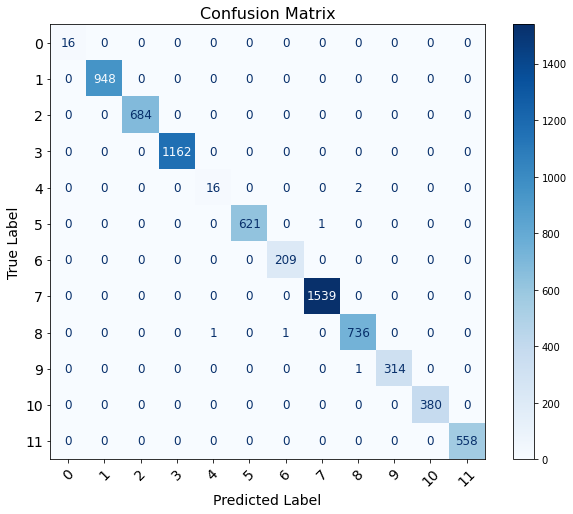

In [10]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)

class_names = labelencoder.classes_

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('Confusion Matrix', fontsize=16)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.tick_params(axis='both', labelsize=14)

for text in ax.texts:
    text.set_fontsize(12)

plt.xticks(rotation=45)
plt.show()

## Identify difficult samples

In [11]:
# Implement a function that performs 5 fold CV on the training set (multiclass) using XGBoost default hyperparameters
# and stores misclassified samples as difficult samples.
def xgb_cv5_misclassified_multiclass(
    X_train,
    y_train,
    n_splits=5,
    random_state=42,
    save_csv_path=None
):
    # 5 fold CV on the training set.
    X_is_df = isinstance(X_train, pd.DataFrame)
    if X_is_df:
        X = X_train
    else:
        X = np.asarray(X_train)
        X = pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])])

    y_raw = np.asarray(y_train).ravel()
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    class_names = le.classes_
    n_classes = len(class_names)

    if n_classes < 3:
        raise ValueError(f"Expected multiclass labels (>=3 classes). Got {n_classes} class(es).")

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    metrics = []
    mistakes_blocks = []

    # Loop over each fold
    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y)), y), start=1):
        X_tr = X.iloc[tr_idx]
        X_va = X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = xgb.XGBClassifier(
            objective="multi:softprob",
            num_class=n_classes,
            random_state=random_state
        )

        t0 = time.time()
        model.fit(X_tr, y_tr)
        train_time = time.time() - t0

        t0 = time.time()
        proba = model.predict_proba(X_va)
        infer_ms_per_sample = (time.time() - t0) / max(len(y_va), 1) * 1000.0

        y_pred = np.argmax(proba, axis=1)

        acc = accuracy_score(y_va, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_va, y_pred, average="weighted", zero_division=0
        )

        metrics.append({
            "fold": fold,
            "train_time_sec": train_time,
            "infer_time_ms_per_sample": infer_ms_per_sample,
            "accuracy": acc,
            "precision_weighted": precision,
            "recall_weighted": recall,
            "f1_weighted": f1,
        })

        wrong_local = np.where(y_pred != y_va)[0]
        wrong_global = va_idx[wrong_local]

        # Store misclassified samples with their original features and additional info
        if len(wrong_global) > 0:
            mistakes_df = X.iloc[wrong_global].copy()

            true_names = class_names[y_va[wrong_local]]
            pred_names = class_names[y_pred[wrong_local]]
            pred_prob = proba[wrong_local, y_pred[wrong_local]]

            mistakes_df["cv_fold"] = fold
            mistakes_df["y_true"] = true_names
            mistakes_df["y_pred"] = pred_names
            mistakes_df["pred_prob_of_y_pred"] = pred_prob

            for j, cname in enumerate(class_names):
                mistakes_df[f"proba_{cname}"] = proba[wrong_local, j]

            mistakes_blocks.append(mistakes_df)

        print(f"\nFold {fold}")
        print(f"Training time (sec): {train_time:.4f}")
        print(f"Testing time per sample (ms): {infer_ms_per_sample:.4f}")
        print(f"Accuracy: {acc*100.0:.3f}%")
        print(f"Precision (weighted): {precision*100.0:.3f}%")
        print(f"Recall (weighted): {recall*100.0:.3f}%")
        print(f"F1 Score (weighted): {f1*100.0:.3f}%")
        print(f"Misclassified in this fold: {len(wrong_local)}")
    
    metrics_df = pd.DataFrame(metrics)
    mistakes_all = pd.concat(mistakes_blocks, axis=0) if len(mistakes_blocks) else X.iloc[[]].copy()

    # Print CV summary and averages
    print("\nCV summary")
    print(metrics_df)
    print("\nAverages")
    print(metrics_df.drop(columns=["fold"]).mean(numeric_only=True))
    print("\nTotal misclassified samples across all folds:", len(mistakes_all))

    # Print class distribution of misclassified samples across all folds
    if len(mistakes_all) > 0 and "y_true" in mistakes_all.columns:
        overall_miscls_counts = mistakes_all["y_true"].value_counts().sort_index()
        overall_miscls_pct = mistakes_all["y_true"].value_counts(normalize=True).sort_index() * 100.0

        print("\nOverall class distribution of misclassified samples across all folds (y_true counts):")
        print(overall_miscls_counts)

        print("\nOverall class distribution of misclassified samples across all folds (y_true percentages):")
        print(overall_miscls_pct.round(3).astype(str) + "%")

    if save_csv_path:
        mistakes_all.to_csv(save_csv_path, index=True)
        print("\nSaved misclassified samples to:", save_csv_path)

    return metrics_df, mistakes_all, le


In [12]:
# Run the 5 fold CV function and get the misclassified samples
metrics_df, mistakes_all, le = xgb_cv5_misclassified_multiclass(
    X_train, y_train,
    n_splits=5,
    random_state=42,
    save_csv_path="xgb_cv5_mistakes_original_structure.csv"
)

[16:29:54] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.

Fold 1
Training time (sec): 5.6024
Testing time per sample (ms): 0.0028
Accuracy: 99.983%
Precision (weighted): 99.983%
Recall (weighted): 99.983%
F1 Score (weighted): 99.982%
Misclassified in this fold: 1
[16:30:00] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.

Fold 2
Training time (sec): 5.2368
Testing time per sample (ms): 0.0019
Accuracy: 99.948%
Precision (weighted): 99.957%
Recall (weighted): 99.948%
F1 Score (weighted): 99

In [13]:
# Display the misclassified samples
mistakes_all

,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,...,proba_2,proba_3,proba_4,proba_5,proba_6,proba_7,proba_8,proba_9,proba_10,proba_11
15370,0.0,0.451613,0.000000,0.000000,0.785711,0.216216,0.5000,0.555556,0.006761,0.020408,...,0.005058,0.004142,0.028326,0.067950,0.004664,0.003876,0.869178,0.002254,0.003751,0.007187
8283,0.0,1.000000,0.727273,0.833333,0.000000,0.959459,0.2500,0.222222,0.000000,0.232653,...,0.000038,0.000062,0.935867,0.000147,0.000217,0.000911,0.061340,0.001079,0.000096,0.000027
9039,0.0,0.403226,0.727273,0.833333,0.514886,0.270270,0.5000,0.555556,0.001221,0.020408,...,0.017892,0.008546,0.835709,0.006688,0.004721,0.012180,0.032580,0.017684,0.026313,0.021612
29784,0.0,0.483871,0.000000,0.000000,0.000000,0.472973,0.8750,0.777778,0.000000,0.000000,...,0.000304,0.000175,0.988035,0.000320,0.000737,0.001065,0.007204,0.000291,0.000197,0.000512
29907,0.0,0.548387,0.454545,0.666667,0.737064,0.432432,0.1250,0.111111,0.091582,0.020408,...,0.000135,0.000137,0.000016,0.000048,0.000054,0.000023,0.000013,0.000088,0.998966,0.000185
3769,0.0,0.338710,0.363636,0.500000,0.000809,0.432432,0.1250,0.111111,0.406526,0.065306,...,0.000084,0.000160,0.984424,0.000164,0.000288,0.000098,0.008478,0.000482,0.003719,0.000153
31153,0.0,0.403226,0.727273,0.833333,0.081684,0.635135,0.0000,0.000000,0.081693,0.065306,...,0.000337,0.001544,0.957361,0.003205,0.000973,0.001004,0.007395,0.002695,0.024491,0.000508
2969,0.0,0.548387,0.454545,0.666667,0.588589,0.432432,0.1250,0.111111,0.016284,0.020408,...,0.000178,0.000620,0.000028,0.000076,0.000099,0.000037,0.000020,0.998280,0.000098,0.000152
23022,0.0,0.483871,0.000000,0.000000,0.806372,0.108108,0.5000,0.555556,0.006761,0.020408,...,0.023854,0.011002,0.763187,0.006186,0.014076,0.036325,0.092695,0.012107,0.003273,0.017973
3107,0.0,0.483871,0.000000,0.000000,0.261181,0.351351,0.5000,0.555556,0.000809,0.065306,...,0.021423,0.007413,0.660932,0.005541,0.010491,0.010951,0.177931,0.037378,0.006363,0.048145


In [14]:
# Drop the extra columns added by CV output
cols_to_drop = [c for c in mistakes_all.columns if c in ["cv_fold", "y_true", "y_pred", "pred_prob_of_y_pred"] or c.startswith("proba_")]
mistakes_clean = mistakes_all.drop(columns=cols_to_drop, errors="ignore").copy()

# Add back the original label column (same name as your dataset)
mistakes_clean["Label"] = mistakes_all["y_true"].astype(str).values

# Split to X_train_mistakes and y_train_mistakes (same structure as original dataset)
X_train_mistakes = mistakes_clean.drop(columns=["Label"]).copy()
y_train_mistakes = mistakes_clean["Label"].copy()


In [15]:
# Display the class distribution of the misclassified samples in y_train_mistakes
y_train_mistakes.value_counts()

8     6
4     5
5     1
1     1
10    1
3     1
7     1
Name: Label, dtype: int64

# Error-Guided Generative Augmentation (EDDA) Using Conditional GAN

In [16]:
# Implement a Conditional GAN (cGAN) to oversample the misclassified samples
import tensorflow as tf
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Input, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Build the generator and discriminator models for the cGAN
def build_cgenerator(latent_dim, n_classes, output_dim, activation="sigmoid"):
    z_in = Input(shape=(latent_dim,), name="z")
    y_in = Input(shape=(n_classes,), name="y_onehot")
    x = Concatenate(name="g_concat")([z_in, y_in])

    x = Dense(128)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization(momentum=0.8)(x)

    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization(momentum=0.8)(x)

    out = Dense(output_dim, activation=activation, name="g_out")(x)
    return Model([z_in, y_in], out, name="cGenerator")

# Discriminator also conditions on the class label
def build_cdiscriminator(input_dim, n_classes):
    x_in = Input(shape=(input_dim,), name="x")
    y_in = Input(shape=(n_classes,), name="y_onehot")
    x = Concatenate(name="d_concat")([x_in, y_in])

    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x)

    x = Dense(128)(x)
    x = LeakyReLU(alpha=0.2)(x)

    out = Dense(1, activation="sigmoid", name="d_out")(x)
    return Model([x_in, y_in], out, name="cDiscriminator")

# Function to set random seeds for reproducibility
def set_tf_seed(seed: int):
    try:
        tf.random.set_seed(seed)  # TF2
    except Exception:
        tf.set_random_seed(seed)  # TF1

# Function to train the cGAN
def train_cgan(
    X_train,
    y_train,
    latent_dim=100,
    batch_size=64,
    epochs=500,
    learning_rate=0.0002,
    beta_1=0.5,
    mode="data_balancing",
    seed=42,
    log_interval=50
):
    """
    Conditional GAN training.
    """

    np.random.seed(seed)
    set_tf_seed(seed)

    X_train_np = X_train.to_numpy(dtype=np.float32) if hasattr(X_train, "to_numpy") else np.asarray(X_train, dtype=np.float32)
    y_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
    y_np = np.asarray(y_np)

    # Keep y dtype consistent
    y_dtype = y_np.dtype

    classes = np.unique(y_np)
    n_classes = len(classes)
    if n_classes < 2:
        raise ValueError("cGAN needs at least 2 classes in the provided training subset.")

    class_to_index = {c: i for i, c in enumerate(classes)}

    def to_onehot(y_vals):
        idx = np.vectorize(class_to_index.get)(y_vals)
        oh = np.zeros((len(y_vals), n_classes), dtype=np.float32)
        oh[np.arange(len(y_vals)), idx] = 1.0
        return oh, idx

    # Safe batch sizing
    effective_bs = int(min(batch_size, max(4, X_train_np.shape[0])))
    if effective_bs != batch_size:
        batch_size = effective_bs

    input_dim = X_train_np.shape[1]

    generator = build_cgenerator(latent_dim, n_classes, input_dim)
    discriminator = build_cdiscriminator(input_dim, n_classes)
    discriminator.compile(
        optimizer=Adam(learning_rate, beta_1),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    discriminator.trainable = False

    # Build the combined GAN model
    z_in = Input(shape=(latent_dim,), name="gan_z")
    y_in = Input(shape=(n_classes,), name="gan_y")
    x_fake = generator([z_in, y_in])
    gan_out = discriminator([x_fake, y_in])
    gan = Model([z_in, y_in], gan_out, name="cGAN")
    gan.compile(optimizer=Adam(learning_rate, beta_1), loss="binary_crossentropy")

    real_labels = np.ones((batch_size, 1), dtype=np.float32)
    fake_labels = np.zeros((batch_size, 1), dtype=np.float32)

    rng = np.random.RandomState(seed)

    # Training loop
    for epoch in range(epochs):
        idx = rng.randint(0, X_train_np.shape[0], batch_size)
        real_x = X_train_np[idx]
        real_y = y_np[idx]
        real_y_oh, _ = to_onehot(real_y)

        noise = rng.normal(0, 1, (batch_size, latent_dim)).astype(np.float32)

        # sample labels for fake batch from observed labels distribution
        fake_y = y_np[rng.randint(0, len(y_np), batch_size)]
        fake_y_oh, _ = to_onehot(fake_y)

        fake_x = generator.predict([noise, fake_y_oh], verbose=0)

        d_loss_real = discriminator.train_on_batch([real_x, real_y_oh], real_labels)
        d_loss_fake = discriminator.train_on_batch([fake_x, fake_y_oh], fake_labels)
        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        loss_weight = min(1.0, (epoch / max(1, epochs)) * 0.5)
        g_loss = gan.train_on_batch([noise, fake_y_oh], real_labels * loss_weight)

        if (log_interval is not None) and (epoch % log_interval == 0):
            print(f"Epoch {epoch}/{epochs} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.5f}] [G loss: {float(g_loss):.5f}]")

    if mode == "data_balancing":
        # return generator plus mapping for consistent conditioning at sampling time
        return generator, classes, class_to_index, y_dtype

    raise ValueError("Invalid mode. Use mode='data_balancing' for your oversampling workflow.")

In [17]:
# Generate synthetic samples using the trained cGAN, conditioned on the mistake samples, and combine with original training data
def gan_generate_from_mistakes(
    X_train_mistakes,
    y_train_mistakes,
    X_train,
    y_train,
    multiplier=10,
    latent_dim=100,
    batch_size=64,
    epochs=300,
    learning_rate=0.0002,
    beta_1=0.5,
    seed=42
):

    X_train_is_df = hasattr(X_train, "columns") and hasattr(X_train, "iloc")
    X_m_is_df = hasattr(X_train_mistakes, "columns") and hasattr(X_train_mistakes, "iloc")

    # Prepare base training data and mistake data as DataFrames for consistent handling
    if X_train_is_df:
        X_base_df = X_train.copy()
        base_cols = list(X_train.columns)
    else:
        X_base_np = np.asarray(X_train, dtype=np.float32)
        base_cols = [f"f{i}" for i in range(X_base_np.shape[1])]
        X_base_df = pd.DataFrame(X_base_np, columns=base_cols)

    if X_m_is_df:
        X_m_df = X_train_mistakes.copy()
    else:
        X_m_df = pd.DataFrame(np.asarray(X_train_mistakes, dtype=np.float32), columns=base_cols)

    y_base = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
    y_base = np.asarray(y_base)
    y_dtype = y_base.dtype

    y_m = y_train_mistakes.to_numpy() if hasattr(y_train_mistakes, "to_numpy") else np.asarray(y_train_mistakes)
    y_m = np.asarray(y_m).astype(y_dtype, copy=False)

    rng = np.random.RandomState(seed)

    # Print class distribution of mistakes and total synthetic samples to generate
    classes_m, counts = np.unique(y_m, return_counts=True)
    n_total = int(len(y_m) * multiplier)
    print("Mistakes per class:")
    for c, n in zip(classes_m, counts):
        print(f"  {c}: {n}")
    print("Total synthetic to generate:", n_total)

    # Train ONE conditional GAN on all mistakes
    cgen, cgan_classes, class_to_index, _ = train_cgan(
        X_m_df,
        y_m,
        latent_dim=latent_dim,
        batch_size=batch_size,
        epochs=epochs,
        learning_rate=learning_rate,
        beta_1=beta_1,
        mode="data_balancing",
        seed=int(rng.randint(0, 1_000_000)),
        log_interval=100
    )

    n_classes = len(cgan_classes)

    def onehot_for_class(c, n):
        if c not in class_to_index:
            raise ValueError(f"Class {c} not seen in cGAN training labels.")
        oh = np.zeros((n, n_classes), dtype=np.float32)
        oh[:, class_to_index[c]] = 1.0
        return oh

    X_syn_parts = []
    y_syn_parts = []

    for c, n_c in zip(classes_m, counts):
        need = int(n_c) * int(multiplier)
        if need <= 0:
            continue

        noise = rng.normal(0, 1, (need, latent_dim)).astype(np.float32)
        y_oh = onehot_for_class(c, need)

        X_syn = cgen.predict([noise, y_oh], verbose=0).astype(np.float32)

        X_syn_parts.append(X_syn)
        y_syn_parts.append(np.full((need,), c, dtype=y_dtype))

    if len(X_syn_parts) == 0:
        X_syn_df = X_base_df.iloc[0:0].copy()
        y_syn = np.asarray([], dtype=y_dtype)
    else:
        X_syn_all = np.concatenate(X_syn_parts, axis=0)
        y_syn = np.concatenate(y_syn_parts, axis=0).astype(y_dtype, copy=False)
        X_syn_df = pd.DataFrame(X_syn_all, columns=base_cols)

    print("Generated synthetic samples:", len(X_syn_df))

    # Combine with original training data
    X_new_df = pd.concat([X_base_df, X_syn_df], axis=0, ignore_index=True)
    y_new = np.concatenate([y_base.astype(y_dtype, copy=False), y_syn], axis=0).astype(y_dtype, copy=False)

    if X_train_is_df:
        X_new = X_new_df[base_cols].copy()
    else:
        X_new = X_new_df.to_numpy(dtype=np.float32)

    if hasattr(y_train, "iloc"):
        y_new = pd.Series(y_new, name=getattr(y_train, "name", None)).astype(y_dtype, copy=False)

    return X_syn_df, y_syn, X_new, y_new

In [27]:
# run the cGAN generation function to create synthetic samples from the misclassified samples and combine with original training data
X_syn_df, y_syn, X_train_new, y_train_new = gan_generate_from_mistakes(
    X_train_mistakes, y_train_mistakes,
    X_train, y_train,
    multiplier=20,
    latent_dim=100,
    batch_size=64,
    epochs=300,
    learning_rate=0.0002,
    beta_1=0.5,
    seed=42
)

X_syn_df.to_csv("gan_synthetic_from_mistakes_X.csv", index=False)
pd.Series(y_syn, name="Label").to_csv("gan_synthetic_from_mistakes_y.csv", index=False)

Mistakes per class:
  1: 1
  3: 1
  4: 5
  5: 1
  7: 1
  8: 6
  10: 1
Total synthetic to generate: 320
Epoch 0/300 [D loss: 0.7850, acc.: 6.25000] [G loss: 0.78185]
Epoch 100/300 [D loss: 0.0087, acc.: 100.00000] [G loss: 0.90078]
Epoch 200/300 [D loss: 0.0177, acc.: 100.00000] [G loss: 3.70996]
Generated synthetic samples: 320


In [28]:
# save the combined new training set as well
if isinstance(X_train_new, pd.DataFrame) and hasattr(y_train_new, "iloc"):
    combined_df = X_train_new.copy()
    combined_df["Label"] = y_train_new.values
    combined_df.to_csv("cgan_augmented_training_set_cic.csv", index=False)


In [29]:
# implement a XGBoost model on the new training set and evaluate on the original test set
model = xgb.XGBClassifier(random_state=42)

# train the model
start = time.time()
model.fit(X_train_new, y_train_new)
end = time.time()
print("Training time: ", end - start)

# make predictions
# print test time per sample
start = time.time()
y_pred = model.predict(X_test)
end = time.time()
print("Testing time (ms): ", (end - start)/len(X_test) * 1000)


# calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy * 100.0))
# print precision, recall, f1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision: %.3f%%" % (precision * 100.0))
print("Recall: %.3f%%" % (recall * 100.0))
print("F1-Score: %.3f%%" % (f1_score * 100.0))

from sklearn.metrics import f1_score as sk_f1_score

macro_f1_score = sk_f1_score(y_test, y_pred, average='macro')
print("Macro-averaged F1-score: %.3f%%" % (macro_f1_score * 100.0))

# calculate the confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# calculate the classification report
class_report = classification_report(y_test, y_pred)
print(class_report)



[16:40:12] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Training time:  9.883784770965576
Testing time (ms):  0.002365149448769931
Accuracy: 99.944%
Precision: 99.944%
Recall: 99.944%
F1-Score: 99.944%
Macro-averaged F1-score: 99.250%
[[  16    0    0    0    0    0    0    0    0    0    0    0]
 [   0  948    0    0    0    0    0    0    0    0    0    0]
 [   0    0  684    0    0    0    0    0    0    0    0    0]
 [   0    0    0 1162    0    0    0    0    0    0    0    0]
 [   0    0    0    0   16    0    0    0    2    0    0    0]
 [   0    0    0    0    0  622    0    0    0    0    0    0]
 [   0    0    0    0    0    0  209    0    0    0    0    0]
 [   0    0    0    0    0    0    0 1539    0    0    0    0]
 [   0

# Hyperparameter Optimization (HPO)

In [30]:
# Hyperparameter tuning on XGBoost using Hyperopt

from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.metrics import f1_score as sk_f1_score

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate']))
    }
    clf = xgb.XGBClassifier(random_state=42, **params)
    clf.fit(X_train_new, y_train_new)
    y_pred = clf.predict(X_test)
    score = sk_f1_score(y_test, y_pred, average='weighted')

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 20, 200, 20),
    'max_depth': hp.quniform('max_depth', 5, 100, 5),
    'learning_rate': hp.uniform('learning_rate', 0.001, 1.0)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['learning_rate'] = abs(float(best['learning_rate']))

print("XGBoost: Hyperopt estimated optimum {}".format(best))

[16:40:30] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[16:40:39] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[16:41:00] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[16:41:18] WARNING: C:/Users/Administrator/workspace/xgboost-win64_

In [31]:
# implement an optimized XGBoost model
model = xgb.XGBClassifier(**best, random_state=42)

# train the model
start = time.time()
model.fit(X_train_new, y_train_new)
end = time.time()
print("Training time: ", end - start)

# make predictions
# print test time per sample
start = time.time()
y_pred = model.predict(X_test)
end = time.time()
print("Testing time (ms): ", (end - start)/len(X_test) * 1000)


# calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy * 100.0))
# print precision, recall, f1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision: %.3f%%" % (precision * 100.0))
print("Recall: %.3f%%" % (recall * 100.0))
print("F1-Score: %.3f%%" % (f1_score * 100.0))

macro_f1_score = sk_f1_score(y_test, y_pred, average='macro')
print("Macro-averaged F1-score: %.3f%%" % (macro_f1_score * 100.0))

# calculate the confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# calculate the classification report
class_report = classification_report(y_test, y_pred)
print(class_report)



[16:45:02] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Training time:  5.740790367126465
Testing time (ms):  0.0019471790283474809
Accuracy: 99.958%
Precision: 99.957%
Recall: 99.958%
F1-Score: 99.958%
Macro-averaged F1-score: 99.269%
[[  16    0    0    0    0    0    0    0    0    0    0    0]
 [   0  948    0    0    0    0    0    0    0    0    0    0]
 [   0    0  684    0    0    0    0    0    0    0    0    0]
 [   0    0    0 1162    0    0    0    0    0    0    0    0]
 [   0    0    0    0   16    0    0    0    2    0    0    0]
 [   0    0    0    0    0  622    0    0    0    0    0    0]
 [   0    0    0    0    0    0  209    0    0    0    0    0]
 [   0    0    0    0    0    0    0 1539    0    0    0    0]
 [   

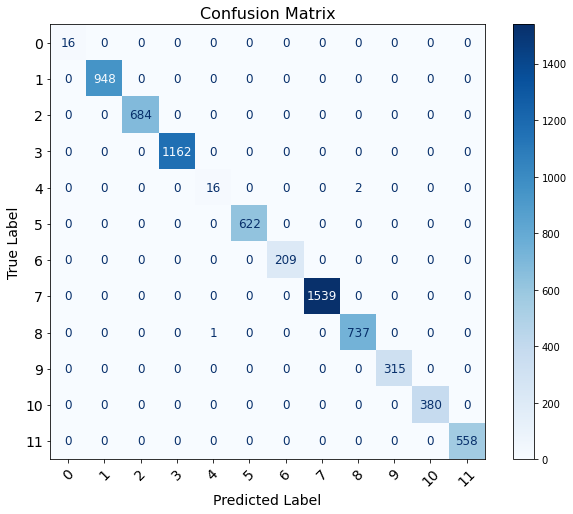

In [32]:
# Plot the confusion matrix

cm = confusion_matrix(y_test, y_pred)

class_names = labelencoder.classes_

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('Confusion Matrix', fontsize=16)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.tick_params(axis='both', labelsize=14)

for text in ax.texts:
    text.set_fontsize(12)

plt.xticks(rotation=45)
plt.show()

In [33]:
# Hyperparameter tuning on XGBoost using Hyperopt and 5 fold CV on the new training set

from hyperopt import hp, fmin, tpe, STATUS_OK, Trials

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate']))
    }

    clf = xgb.XGBClassifier(random_state=42, **params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        clf,
        X_train_new,
        y_train_new,
        cv=cv,
        scoring='f1_weighted'
    )
    score = scores.mean()

    return {'loss': -score, 'status': STATUS_OK}

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 20, 300, 10),
    'max_depth': hp.quniform('max_depth', 5, 100, 5),
    'learning_rate': hp.uniform('learning_rate', 0.001, 1.0)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['learning_rate'] = abs(float(best['learning_rate']))

print("XGBoost: Hyperopt estimated optimum {}".format(best))

[16:45:17] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[16:45:22] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[16:45:26] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[16:45:31] WARNING: C:/Users/Administrator/workspace/xgboost-win64_

In [34]:
# implement an optimized XGBoost model
model = xgb.XGBClassifier(**best, random_state=42)

# train the model
start = time.time()
model.fit(X_train_new, y_train_new)
end = time.time()
print("Training time: ", end - start)

# make predictions
# print test time per sample
start = time.time()
y_pred = model.predict(X_test)
end = time.time()
print("Testing time (ms): ", (end - start)/len(X_test) * 1000)


# calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy * 100.0))
# print precision, recall, f1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
print("Precision: %.3f%%" % (precision * 100.0))
print("Recall: %.3f%%" % (recall * 100.0))
print("F1-Score: %.3f%%" % (f1_score * 100.0))

from sklearn.metrics import f1_score as sk_f1_score

macro_f1_score = sk_f1_score(y_test, y_pred, average='macro')
print("Macro-averaged F1-score: %.3f%%" % (macro_f1_score * 100.0))

# calculate the confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# calculate the classification report
class_report = classification_report(y_test, y_pred)
print(class_report)



[17:12:28] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Training time:  32.897374868392944
Testing time (ms):  0.004312361641476724
Accuracy: 99.944%
Precision: 99.944%
Recall: 99.944%
F1-Score: 99.944%
Macro-averaged F1-score: 99.250%
[[  16    0    0    0    0    0    0    0    0    0    0    0]
 [   0  948    0    0    0    0    0    0    0    0    0    0]
 [   0    0  684    0    0    0    0    0    0    0    0    0]
 [   0    0    0 1162    0    0    0    0    0    0    0    0]
 [   0    0    0    0   16    0    0    0    2    0    0    0]
 [   0    0    0    0    0  622    0    0    0    0    0    0]
 [   0    0    0    0    0    0  209    0    0    0    0    0]
 [   0    0    0    0    0    0    0 1539    0    0    0    0]
 [   